# Function 5 Analysis - Week 4

This notebook contains the exploratory analysis for **Function 5** in Week 4. We continue to focus on an exploitation strategy around the best observed peak, now with **23 datapoints** after adding the last three weeks’ measurements.

**Function Description:** 	
You’re tasked with optimising a four-variable black-box function that represents the yield of a chemical process in a factory. The function is typically unimodal, with a single peak where yield is maximised. Your goal is to find the optimal combination of chemical inputs that delivers the highest possible yield, using systematic exploration and optimisation methods.

## Loading and Displaying the Data

We load the inputs and outputs for function 5 and display them in a table format. The best outputs cluster around high x2–x4 and low x1. The Week 3 point `(0.203491, 0.849529, 0.982723, 0.925116)` returned **2066.67**, setting a new maximum and reinforcing the exploitation-focused strategy.


In [19]:
from pathlib import Path
import numpy as np, pandas as pd, seaborn as sns, matplotlib.pyplot as plt
sns.set_theme(style="ticks", context="notebook")
path = Path("../../initial_data/function_5")
X = np.load(path / "initial_inputs.npy")
y = np.load(path / "initial_outputs.npy")

# Week 1, Week 2, and Week 3 new points
X_new_point_week_1 = np.array([[0.191447, 0.846480, 0.879484, 0.878516]])
y_new_point_week_1 = np.array([1086.3644542213872])
X_new_point_week_2 = np.array([[0.202624, 0.849188, 0.971974, 0.920186]])
y_new_point_week_2 = np.array([1935.0092608386958])
X_new_point_week_3 = np.array([[0.203491, 0.849529, 0.982723, 0.925116]])
y_new_point_week_3 = np.array([2066.674475985541])

X = np.vstack([X, X_new_point_week_1, X_new_point_week_2, X_new_point_week_3])
y = np.concatenate([y, y_new_point_week_1, y_new_point_week_2, y_new_point_week_3])

df = pd.DataFrame(X, columns=["x1", "x2", "x3", "x4"]); df["y"] = y
display(df)
print("df sorted by y")
df_sorted = df.sort_values("y", ascending=False).reset_index(drop=True)
df_sorted["x_avg"] = df_sorted[["x1", "x2", "x3", "x4"]].mean(axis=1)
display(df_sorted)


,x1,x2,x3,x4,y
0,0.191447,0.038193,0.607418,0.414584,64.443440
1,0.758653,0.536518,0.656000,0.360342,18.301380
2,0.438350,0.804340,0.210245,0.151295,0.112940
3,0.706051,0.534192,0.264243,0.482088,4.210898
4,0.836478,0.193610,0.663893,0.785649,258.370525
5,0.683432,0.118663,0.829046,0.567577,78.434389
6,0.553621,0.667350,0.323806,0.814870,57.571537
7,0.352356,0.322242,0.116979,0.473113,109.571876
8,0.153786,0.729382,0.422598,0.443074,8.847992
9,0.463442,0.630025,0.107906,0.957644,233.223610


df sorted by y


,x1,x2,x3,x4,y,x_avg
0,0.203491,0.849529,0.982723,0.925116,2066.674476,0.740215
1,0.202624,0.849188,0.971974,0.920186,1935.009261,0.735993
2,0.224189,0.846480,0.879484,0.878516,1088.859618,0.707167
3,0.191447,0.846480,0.879484,0.878516,1086.364454,0.698982
4,0.119879,0.862540,0.643331,0.849804,431.612757,0.618889
5,0.438933,0.774092,0.378167,0.933696,355.806818,0.631222
6,0.836478,0.193610,0.663893,0.785649,258.370525,0.619907
7,0.463442,0.630025,0.107906,0.957644,233.223610,0.539754
8,0.352356,0.322242,0.116979,0.473113,109.571876,0.316172
9,0.511142,0.817957,0.728710,0.112354,79.729130,0.542541


**Observations:**
- **Week 1:** `(0.191447, 0.846480, 0.879484, 0.878516)` yielded ≈1086.
- **Week 2:** `(0.202624, 0.849188, 0.971974, 0.920186)` yielded ≈**1935**, then our max.
- **Week 3:** `(0.203491, 0.849529, 0.982723, 0.925116)` yielded **2066.67**, setting a new maximum.
- Best outputs cluster around high x2–x4 (≈0.85–0.98) and low x1 (≈0.19–0.21), consistent with the `x234_prod` signal.
- The function still appears unimodal around this ridge; recent gains validate the exploitation-focused approach.


## Product feature: x2·x3·x4

The strongest signal comes from the simple product `x234_prod = x2 * x3 * x4`. We focus on this single feature and visualize it against y; no other derived features or candidate selection logic are needed.


In [20]:
# Focus on the single product feature

# Product of x2-x4 (multiplicative interaction)
df_analysis = df.copy()
df_analysis["x234_prod"] = df_analysis["x2"] * df_analysis["x3"] * df_analysis["x4"]

# Correlation of x234_prod with y
correlations = df_analysis[["x234_prod", "y"]].corr()["y"]
print("Correlation (x234_prod, y):")
print("=" * 40)
print(f"x234_prod: {correlations['x234_prod']:.4f}")


Correlation (x234_prod, y):
x234_prod: 0.9339


## Visualization of x234_prod

We visualize the relationship between `x234_prod` (product of x2, x3, x4) and y, which shows the highest correlation (≈0.93) among all features.


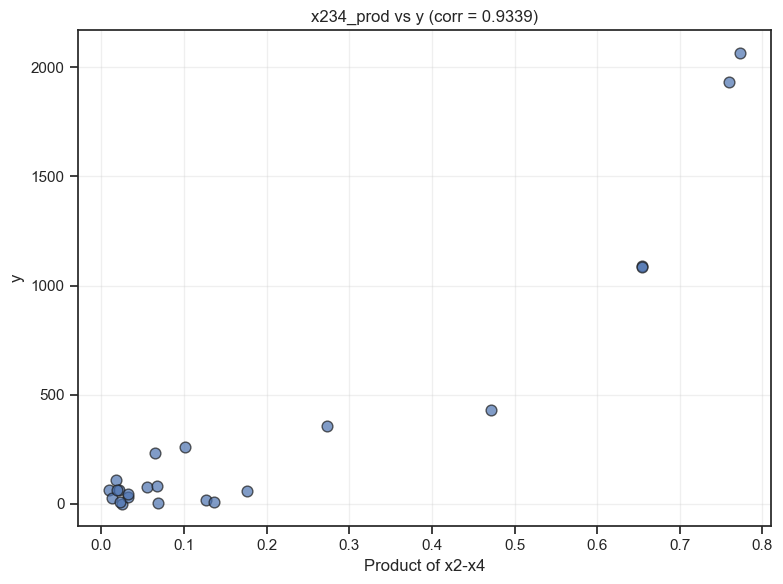

In [21]:
# Visualize x234_prod vs y
plt.figure(figsize=(8, 6))
plt.scatter(df_analysis["x234_prod"], df_analysis["y"], alpha=0.7, edgecolors='k', s=60)
plt.xlabel("Product of x2-x4")
plt.ylabel("y")
plt.title(f"x234_prod vs y (corr = {correlations['x234_prod']:.4f})")
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()


## Insight: product drives the ridge

- `x234_prod = x2*x3*x4` has the strongest correlation with y (≈0.93).
- The optimal region corresponds to high `x234_prod`; we use a fixed floor (0.76) to stay on that ridge while the optimizer chooses the composition.


In [22]:
# Use x234_prod (highest correlation) to constrain search space
best_feature = "x234_prod"
# Fixed target floor: encourage the optimizer to hit x234_prod ≥ 0.76
feature_threshold = 0.76

print("=" * 60)
print("Constraint Setup")
print("=" * 60)
print(f"Using {best_feature} (correlation = {correlations['x234_prod']:.4f})")
print(f"Fixed target floor: {feature_threshold:.4f}")
print(f"Constraint: {best_feature} >= {feature_threshold:.4f}")
print("=" * 60)


Constraint Setup
Using x234_prod (correlation = 0.9339)
Fixed target floor: 0.7600
Constraint: x234_prod >= 0.7600


## Gaussian Process Model for Exploitation

We fit a Gaussian Process regressor on the original 4D space (x1, x2, x3, x4). **Note:** We don't add `x234_prod` as an input since it's redundant (the GP can learn it from x2, x3, x4). We use the product insight to **constrain the search space** with a fixed floor `x234_prod ≥ 0.76`. For exploitation, we maximize the **GP mean** using a **smoother RBF kernel** (length_scale ~0.5, bounds [1e-2, 2]) and a higher noise term (alpha=1e-4) to reflect expected taste-test noise.
- We've confirmed the function is unimodal with a single peak
- Week 3 reached 2066.67; we stay near that ridge
- The `x234_prod` floor keeps us in the high-yield ridge while letting the optimizer pick the composition
- Exploitation allows us to refine the peak location


In [23]:
from sklearn.gaussian_process import GaussianProcessRegressor
from sklearn.gaussian_process.kernels import RBF, ConstantKernel
from sklearn.preprocessing import StandardScaler

# Standardize inputs and outputs for better GP performance
# Keep GP on original 4D space (x1, x2, x3, x4) - no redundant features
scaler_X = StandardScaler()
scaler_y = StandardScaler()
X_scaled = scaler_X.fit_transform(X)
y_scaled = scaler_y.fit_transform(y.reshape(-1, 1)).ravel()

# Define kernel: smoother RBF with reasonable length scales; expect notable noise in taste data
kernel = ConstantKernel(1.0, (1e-3, 1e3)) * RBF(length_scale=0.5, length_scale_bounds=(1e-2, 2.0))

# Fit GP (higher alpha to accommodate taste noise)
gp = GaussianProcessRegressor(kernel=kernel, n_restarts_optimizer=10, alpha=1e-4, normalize_y=False)
gp.fit(X_scaled, y_scaled)

print(f"GP fitted on 4D space (x1, x2, x3, x4)")
print(f"Using {best_feature} constraint (>= {feature_threshold:.4f}) to guide search")
print(f"Optimized kernel: {gp.kernel_}")
print(f"Log-marginal-likelihood: {gp.log_marginal_likelihood(gp.kernel_.theta):.2f}")


GP fitted on 4D space (x1, x2, x3, x4)
Using x234_prod constraint (>= 0.7600) to guide search
Optimized kernel: 0.817**2 * RBF(length_scale=0.246)
Log-marginal-likelihood: -25.45


## Bayesian Optimization with Constraint

We use Bayesian optimization to find the next point to evaluate. The optimization maximizes the GP mean prediction (pure exploitation) while using a **soft constraint** based on `x234_prod`. 

**How the constraint works:** The constraint is applied **during optimization**, not as a post-filter. The objective adds a penalty when `x234_prod` falls below a **fixed target floor of 0.76**. This actively guides the optimizer toward the high-yield ridge; it can be relaxed later (by lowering the floor or penalty) if gains plateau.

This approach leverages our insight that `x234_prod` strongly correlates with y (correlation ≈ 0.93) without adding redundant features to the GP model.

In [24]:
from scipy.optimize import differential_evolution

# Define objective: negative GP mean (to maximize mean, we minimize negative mean)
# Use constraint based on x234_prod to focus search
def negative_gp_mean(x):
    # Compute x234_prod from x2, x3, x4
    x234_prod_val = x[1] * x[2] * x[3]
    
    # Penalize if x234_prod is below threshold (soft constraint)
    # This guides the search towards high x234_prod regions
    penalty = 0.0
    if x234_prod_val < feature_threshold:
        penalty = 1000.0 * (feature_threshold - x234_prod_val)  # Large penalty for low values
    
    # Predict with GP (on 4D space)
    x_scaled = scaler_X.transform(x.reshape(1, -1))
    mu_scaled = gp.predict(x_scaled, return_std=False)
    mu = scaler_y.inverse_transform(mu_scaled.reshape(-1, 1)).ravel()[0]
    return -mu + penalty

# Optimize over [0, 1]^4 with constraint
bounds = [(0, 1)] * 4
result = differential_evolution(negative_gp_mean, bounds, seed=42, maxiter=1000, atol=1e-7, tol=1e-7)

# Extract recommended point
x_next = result.x

# Get actual GP prediction (without penalty)
x_next_scaled = scaler_X.transform(x_next.reshape(1, -1))
mu_scaled = gp.predict(x_next_scaled, return_std=False)
y_next_pred = scaler_y.inverse_transform(mu_scaled.reshape(-1, 1)).ravel()[0]

# Compute x234_prod for the recommended point
x234_prod_next = x_next[1] * x_next[2] * x_next[3]

print("=" * 60)
print(f"RECOMMENDED NEXT POINT (Pure Exploitation via GP Mean)")
print(f"Search constrained by x234_prod >= {feature_threshold:.4f}")
print("=" * 60)
print(f"x1 = {x_next[0]:.6f}")
print(f"x2 = {x_next[1]:.6f}")
print(f"x3 = {x_next[2]:.6f}")
print(f"x4 = {x_next[3]:.6f}")
print(f"x234_prod = {x234_prod_next:.6f} {'✓' if x234_prod_next >= feature_threshold else '⚠ (below threshold)'}")
print(f"\nPredicted output: {y_next_pred:.2f}")
print(f"Current best observed: {y.max():.2f} (at observation {y.argmax()})")
print("=" * 60)


RECOMMENDED NEXT POINT (Pure Exploitation via GP Mean)
Search constrained by x234_prod >= 0.7600
x1 = 0.206189
x2 = 0.850311
x3 = 1.000000
x4 = 0.936243
x234_prod = 0.796098 ✓

Predicted output: 2191.34
Current best observed: 2066.67 (at observation 22)


## Summary

**Strategy:** Pure exploitation via GP mean maximization with `x234_prod` constraint.

**Key Insights:**
- `x234_prod` (product of x2, x3, x4) remains the strongest signal (corr ≈0.93), aligning with the new max.
- Best points: Week 2 =1935 `(0.203491, 0.849529, 0.982723, 0.925116, 2066.674476)`
, Week 3 **2066.67** at `(0.203491, 0.849529, 0.982723, 0.925116)`.

**Approach:**
- GP on original 4D space (no redundant features), exploitation-focused.
- Soft constraint on `x234_prod` uses a fixed floor (0.76) to stay on the high-yield ridge; penalty can be relaxed later if gains plateau.

**Kernel / constraint check:**
- Optimized kernel (current run): `0.817**2 * RBF(length_scale=0.246)`; length-scale bounds [1e-2, 2.0].
- Keep the product floor for now; ease the penalty/floor only if improvements flatten and you want mild exploration.
- Higher expected taste noise: using smoother RBF and higher alpha (1e-4) to absorb noise while keeping reasonable length scales.

**Next Steps:**
- Treat 2066.67 as the incumbent; rerun the BO cell to refresh the recommendation with the added data.
- Continue exploitation with the current constraint; relax only if gains stall.
